In [ ]:
!pip install -q transformers accelerate bitsandbytes sentence-transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.8 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto"
)

print("✅ Mistral 7B Loaded Successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

✅ Mistral 7B Loaded Successfully


In [ ]:
print(next(model.parameters()).device)

cuda:0


In [ ]:
prompt = "Explain Retrieval-Augmented Generation in simple words."

inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=100
)

response = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(response)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


Explain Retrieval-Augmented Generation in simple words.

Retrieval-Augmented Generation (RAG) is a type of artificial intelligence (AI) model that combines the strengths of two different AI techniques: Retrieval and Generation.

Retrieval refers to the ability of a model to access and understand large amounts of text data, often from external sources. This is useful for answering factual questions or providing information on specific topics.

Generation, on the other hand, refers to the ability of a model to


In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset
import pandas as pd

In [ ]:
dataset = load_dataset("deepmind/narrativeqa")

Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['document', 'question', 'answers'],
        num_rows: 32747
    })
    test: Dataset({
        features: ['document', 'question', 'answers'],
        num_rows: 10557
    })
    validation: Dataset({
        features: ['document', 'question', 'answers'],
        num_rows: 3461
    })
})


In [ ]:
test_dataset = dataset["test"]

print("Total Test Samples:", len(test_dataset))

Total Test Samples: 10557


In [ ]:
subset_dataset = test_dataset.select(range(200))

print("Subset Size:", len(subset_dataset))

Subset Size: 200


In [ ]:
sample = subset_dataset[0]

print(sample)

{'document': {'id': '0025577043f5090cd603c6aea60f26e236195594', 'kind': 'movie', 'url': 'http://www.awesomefilm.com/script/pumpupthevolume.html', 'file_size': 54078, 'word_count': 11499, 'start': 'Happy Harry Hardon', 'end': 'by Martin Eaves', 'summary': {'text': ' Mark Hunter (Slater), a high school student in a sleepy suburb of Phoenix, Arizona, starts an FM pirate radio station that broadcasts from the basement of his parents\' house. Mark is a loner, an outsider, whose only outlet for his teenage angst and aggression is his unauthorized radio station. His pirate station\'s theme song is "Everybody Knows" by Leonard Cohen and there are glimpses of cassettes by such alternative musicians as The Jesus and Mary Chain, Camper Van Beethoven, Primal Scream, Soundgarden, Ice-T, Bad Brains, Concrete Blonde, Henry Rollins, and The Pixies. By day, Mark is seen as a loner, hardly talking to anyone around him; by night, he expresses his outsider views about what is wrong with American society. 

In [ ]:
document_text = sample["document"]["text"]
question_text = sample["question"]["text"]
reference_answer = sample["answers"][0]["text"]

print("QUESTION:\n")
print(question_text)

print("\nREFERENCE ANSWER:\n")
print(reference_answer)

print("\nDOCUMENT LENGTH:\n")
print(len(document_text))

QUESTION:

Who is Mark Hunter?

REFERENCE ANSWER:

He is a high school student in Phoenix.

DOCUMENT LENGTH:

54078


In [ ]:
processed_data = []

for item in subset_dataset:
    processed_item = {
        "document": item["document"]["text"],
        "question": item["question"]["text"],
        "reference_answer": item["answers"][0]["text"]
    }

    processed_data.append(processed_item)

print("Processed Samples:", len(processed_data))

Processed Samples: 200


In [ ]:
processed_data[0]

{'document': '<html><title>Pump Up The Volume Transcript</title><pre>\nHappy Harry Hardon - Did you ever get the feeling that everything in America is \ncompletely fucked up. You know that feeling that the whole country is like one inch \naway from saying \'That\'s it, forget it.\' You think about it. Everything is polluted. The \nenvironment, the government, the schools you name it. Speaking of schools. I was \nwalking the households the other day and I asked myself. Is there live after high school? \nBecause I can\'t face tomorrow, let alone a whole year of this shit. Yeah, you got it folks. \nIt\'s me again with a little attitude for all you out here and waiting for Atlanta. All you \nnice people living in the middle of America the beautiful. Lets see, we\'re on er 92 FM \ntonight and it feels like a nice clean little band so far. No one else is using it. The price is \nright. Heh, heh. And yes folks you guest it. Tonight I am as horny as a ten peckerd house, \nso stay tuned because

In [ ]:
!pip install -q langchain langchain-community langchain-huggingface faiss-cpu sentence-transformers

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_huggingface import HuggingFaceEmbeddings

In [ ]:
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

print("✅ Embedding Model Loaded")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Embedding Model Loaded


In [ ]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,
    chunk_overlap=50
)

print("✅ Text Splitter Ready")

✅ Text Splitter Ready


In [ ]:
processed_data = []

for item in subset_dataset:
    processed_item = {
        "document": item["document"]["text"],
        "question": item["question"]["text"],
        "reference_answer": item["answers"][0]["text"]
    }

    processed_data.append(processed_item)

print("✅ Processed Samples:", len(processed_data))

✅ Processed Samples: 200


In [ ]:
sample_document = processed_data[0]["document"]

chunks = text_splitter.split_text(sample_document)

print("Total Chunks:", len(chunks))

print("\nFIRST CHUNK:\n")
print(chunks[0][:500])

Total Chunks: 142

FIRST CHUNK:

<html><title>Pump Up The Volume Transcript</title><pre>
Happy Harry Hardon - Did you ever get the feeling that everything in America is 
completely fucked up. You know that feeling that the whole country is like one inch 
away from saying 'That's it, forget it.' You think about it. Everything is polluted. The 
environment, the government, the schools you name it. Speaking of schools. I was 
walking the households the other day and I asked myself. Is there live after high school?


In [ ]:
vector_store = FAISS.from_texts(
    texts=chunks,
    embedding=embedding_model
)

print("✅ FAISS Vector Store Created")

✅ FAISS Vector Store Created


In [ ]:
question = processed_data[0]["question"]

retrieved_docs = vector_store.similarity_search(
    question,
    k=5
)

print("Retrieved Chunks:", len(retrieved_docs))

print("\nFIRST RETRIEVED CHUNK:\n")
print(retrieved_docs[0].page_content[:500])

Retrieved Chunks: 5

FIRST RETRIEVED CHUNK:

Mark - I don't think so, no!

Nora - I'm the eat me beat me lady!   So you don't believe me. "I know you, not your 
name, but your game. I know the true you, come to me or I'll come to you."  Hey relax, 
I'm not really like that, except when I am.

Mark - Look it's not your fault. I was listening last night. I didn't think he'd go through 
with it.

<The Hunter dining table>

Marla - Mark,  we heard about Malcolm Kaiser, we know.

Brian - We were just wondering if you knew him?

Mark - No not re


In [ ]:
def create_rag_prompt(context, question):
    prompt = f"""
You are an intelligent AI assistant.

Use ONLY the provided context to answer the question.

Context:
{context}

Question:
{question}

Answer:
"""
    return prompt

print("✅ Prompt Template Ready")

✅ Prompt Template Ready


In [ ]:
retrieved_contexts = [doc.page_content for doc in retrieved_docs]

combined_context = "\n\n".join(retrieved_contexts)

print(combined_context[:1000])

Mark - I don't think so, no!

Nora - I'm the eat me beat me lady!   So you don't believe me. "I know you, not your 
name, but your game. I know the true you, come to me or I'll come to you."  Hey relax, 
I'm not really like that, except when I am.

Mark - Look it's not your fault. I was listening last night. I didn't think he'd go through 
with it.

<The Hunter dining table>

Marla - Mark,  we heard about Malcolm Kaiser, we know.

Brian - We were just wondering if you knew him?

Mark - No not really.

Brian Hunter - I am the system, yeah. Is that a beer?

Mark Hunter (Happy Harry Hardon) - Sure!

Marla Hunter - Have you notice his behaviour lately?

Brian Hunter - What about him?

Marla Hunter - He's just so unhappy here.

Brian Hunter - I'll go talk to him.

<Brian's Study>

Brian Hunter - Hi, what's up?

Mark - I was just looking for some stamps.

Brian Hunter - Oh fine, I got some right here. Sending a letter to one of your friends back 
east?

Mark (Reads silently) - "You're the vo

In [ ]:
rag_prompt = create_rag_prompt(
    combined_context,
    question
)

print(rag_prompt[:1500])


You are an intelligent AI assistant.

Use ONLY the provided context to answer the question.

Context:
Mark - I don't think so, no!

Nora - I'm the eat me beat me lady!   So you don't believe me. "I know you, not your 
name, but your game. I know the true you, come to me or I'll come to you."  Hey relax, 
I'm not really like that, except when I am.

Mark - Look it's not your fault. I was listening last night. I didn't think he'd go through 
with it.

<The Hunter dining table>

Marla - Mark,  we heard about Malcolm Kaiser, we know.

Brian - We were just wondering if you knew him?

Mark - No not really.

Brian Hunter - I am the system, yeah. Is that a beer?

Mark Hunter (Happy Harry Hardon) - Sure!

Marla Hunter - Have you notice his behaviour lately?

Brian Hunter - What about him?

Marla Hunter - He's just so unhappy here.

Brian Hunter - I'll go talk to him.

<Brian's Study>

Brian Hunter - Hi, what's up?

Mark - I was just looking for some stamps.

Brian Hunter - Oh fine, I got some 

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [ ]:
!pip install -U bitsandbytes

In [ ]:
sample_document = processed_data[0]["document"]

chunks = text_splitter.split_text(sample_document)

print("Total Chunks:", len(chunks))

print("\nFIRST CHUNK:\n")
print(chunks[0][:500])

Total Chunks: 142

FIRST CHUNK:

<html><title>Pump Up The Volume Transcript</title><pre>
Happy Harry Hardon - Did you ever get the feeling that everything in America is 
completely fucked up. You know that feeling that the whole country is like one inch 
away from saying 'That's it, forget it.' You think about it. Everything is polluted. The 
environment, the government, the schools you name it. Speaking of schools. I was 
walking the households the other day and I asked myself. Is there live after high school?


In [ ]:
vector_store = FAISS.from_texts(
    texts=chunks,
    embedding=embedding_model
)

print("✅ FAISS Vector Store Created")

✅ FAISS Vector Store Created


In [ ]:
question = processed_data[0]["question"]

retrieved_docs = vector_store.similarity_search(
    question,
    k=5
)

print("Retrieved Chunks:", len(retrieved_docs))

print("\nFIRST RETRIEVED CHUNK:\n")
print(retrieved_docs[0].page_content[:500])

Retrieved Chunks: 5

FIRST RETRIEVED CHUNK:

Mark - I don't think so, no!

Nora - I'm the eat me beat me lady!   So you don't believe me. "I know you, not your 
name, but your game. I know the true you, come to me or I'll come to you."  Hey relax, 
I'm not really like that, except when I am.

Mark - Look it's not your fault. I was listening last night. I didn't think he'd go through 
with it.

<The Hunter dining table>

Marla - Mark,  we heard about Malcolm Kaiser, we know.

Brian - We were just wondering if you knew him?

Mark - No not re


In [ ]:
def create_rag_prompt(context, question):
    prompt = f"""
You are an intelligent AI assistant.

Use ONLY the provided context to answer the question.

Context:
{context}

Question:
{question}

Answer:
"""
    return prompt

print("✅ Prompt Template Ready")

✅ Prompt Template Ready


In [ ]:
retrieved_contexts = [doc.page_content for doc in retrieved_docs]

combined_context = "\n\n".join(retrieved_contexts)

print(combined_context[:1000])

Mark - I don't think so, no!

Nora - I'm the eat me beat me lady!   So you don't believe me. "I know you, not your 
name, but your game. I know the true you, come to me or I'll come to you."  Hey relax, 
I'm not really like that, except when I am.

Mark - Look it's not your fault. I was listening last night. I didn't think he'd go through 
with it.

<The Hunter dining table>

Marla - Mark,  we heard about Malcolm Kaiser, we know.

Brian - We were just wondering if you knew him?

Mark - No not really.

Brian Hunter - I am the system, yeah. Is that a beer?

Mark Hunter (Happy Harry Hardon) - Sure!

Marla Hunter - Have you notice his behaviour lately?

Brian Hunter - What about him?

Marla Hunter - He's just so unhappy here.

Brian Hunter - I'll go talk to him.

<Brian's Study>

Brian Hunter - Hi, what's up?

Mark - I was just looking for some stamps.

Brian Hunter - Oh fine, I got some right here. Sending a letter to one of your friends back 
east?

Mark (Reads silently) - "You're the vo

In [ ]:
rag_prompt = create_rag_prompt(
    combined_context,
    question
)

print(rag_prompt[:1500])


You are an intelligent AI assistant.

Use ONLY the provided context to answer the question.

Context:
Mark - I don't think so, no!

Nora - I'm the eat me beat me lady!   So you don't believe me. "I know you, not your 
name, but your game. I know the true you, come to me or I'll come to you."  Hey relax, 
I'm not really like that, except when I am.

Mark - Look it's not your fault. I was listening last night. I didn't think he'd go through 
with it.

<The Hunter dining table>

Marla - Mark,  we heard about Malcolm Kaiser, we know.

Brian - We were just wondering if you knew him?

Mark - No not really.

Brian Hunter - I am the system, yeah. Is that a beer?

Mark Hunter (Happy Harry Hardon) - Sure!

Marla Hunter - Have you notice his behaviour lately?

Brian Hunter - What about him?

Marla Hunter - He's just so unhappy here.

Brian Hunter - I'll go talk to him.

<Brian's Study>

Brian Hunter - Hi, what's up?

Mark - I was just looking for some stamps.

Brian Hunter - Oh fine, I got some 

In [ ]:
inputs = tokenizer(
    rag_prompt,
    return_tensors="pt",
    truncation=True,
    max_length=2048
).to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=150,
    temperature=0.3
)

generated_answer = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

print(generated_answer)

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.



You are an intelligent AI assistant.

Use ONLY the provided context to answer the question.

Context:
Mark - I don't think so, no!

Nora - I'm the eat me beat me lady!   So you don't believe me. "I know you, not your 
name, but your game. I know the true you, come to me or I'll come to you."  Hey relax, 
I'm not really like that, except when I am.

Mark - Look it's not your fault. I was listening last night. I didn't think he'd go through 
with it.

<The Hunter dining table>

Marla - Mark,  we heard about Malcolm Kaiser, we know.

Brian - We were just wondering if you knew him?

Mark - No not really.

Brian Hunter - I am the system, yeah. Is that a beer?

Mark Hunter (Happy Harry Hardon) - Sure!

Marla Hunter - Have you notice his behaviour lately?

Brian Hunter - What about him?

Marla Hunter - He's just so unhappy here.

Brian Hunter - I'll go talk to him.

<Brian's Study>

Brian Hunter - Hi, what's up?

Mark - I was just looking for some stamps.

Brian Hunter - Oh fine, I got some 

In [ ]:
import json
from tqdm import tqdm

In [ ]:
def clean_generated_answer(full_output):
    if "Answer:" in full_output:
        return full_output.split("Answer:")[-1].strip()
    return full_output.strip()

print("✅ Answer Cleaning Function Ready")

✅ Answer Cleaning Function Ready


In [ ]:
test_rag_results = []

small_subset = processed_data[:3]

for item in tqdm(small_subset):

    document = item["document"]
    question = item["question"]
    reference_answer = item["reference_answer"]

    # Split document into chunks
    chunks = text_splitter.split_text(document)

    # Create FAISS vector store
    vector_store = FAISS.from_texts(
        texts=chunks,
        embedding=embedding_model
    )

    # Retrieve top-5 chunks
    retrieved_docs = vector_store.similarity_search(
        question,
        k=5
    )

    # Extract retrieved contexts
    retrieved_contexts = [
        doc.page_content for doc in retrieved_docs
    ]

    # Combine contexts
    combined_context = "\n\n".join(retrieved_contexts)

    # Create RAG prompt
    rag_prompt = create_rag_prompt(
        combined_context,
        question
    )

    # Tokenize input
    inputs = tokenizer(
        rag_prompt,
        return_tensors="pt",
        truncation=True,
        max_length=2048
    ).to("cuda")

    # Generate answer
    outputs = model.generate(
        **inputs,
        max_new_tokens=150
    )

    # Decode output
    generated_text = tokenizer.decode(
        outputs[0],
        skip_special_tokens=True
    )

    # Clean answer
    cleaned_answer = clean_generated_answer(
        generated_text
    )

    # Store result
    result = {
        "question": question,
        "generated_answer": cleaned_answer,
        "reference_answer": reference_answer,
        "retrieved_contexts": retrieved_contexts
    }

    test_rag_results.append(result)

print("✅ Small RAG Test Completed")

100%|██████████| 3/3 [00:25<00:00,  8.59s/it]

✅ Small RAG Test Completed


In [ ]:
test_rag_results[0]

{'question': 'Who is Mark Hunter?',
 'generated_answer': 'Mark Hunter is a character in the context who is described as a student at Hupert Humphrey University. He is often quiet and keeps to himself, and there are concerns about his behavior and unhappiness at the school. He is also the recipient of mysterious letters from someone named Nora, who claims to know him and his true identity. Mark seems to be struggling with some inner turmoil and is unable to openly express himself or confront the situation.',
 'reference_answer': 'He is a high school student in Phoenix.',
 'retrieved_contexts': ['Mark - I don\'t think so, no!\n\nNora - I\'m the eat me beat me lady!   So you don\'t believe me. "I know you, not your \nname, but your game. I know the true you, come to me or I\'ll come to you."  Hey relax, \nI\'m not really like that, except when I am.\n\nMark - Look it\'s not your fault. I was listening last night. I didn\'t think he\'d go through \nwith it.\n\n<The Hunter dining table>\n\n

In [ ]:
import os

os.makedirs("results", exist_ok=True)

print("✅ Results Folder Ready")

✅ Results Folder Ready


In [ ]:
rag_results = []

full_processed_data = processed_data[:200]

for item in tqdm(full_processed_data):

    try:

        document = item["document"]
        question = item["question"]
        reference_answer = item["reference_answer"]

        # Split document into chunks
        chunks = text_splitter.split_text(document)

        # Speed optimization
        chunks = chunks[:30]

        # Create FAISS vector store
        vector_store = FAISS.from_texts(
            texts=chunks,
            embedding=embedding_model
        )

        # Retrieve top-3 chunks
        retrieved_docs = vector_store.similarity_search(
            question,
            k=3
        )

        # Extract retrieved contexts
        retrieved_contexts = [
            doc.page_content for doc in retrieved_docs
        ]

        # Combine contexts
        combined_context = "\n\n".join(retrieved_contexts)

        # Create prompt
        rag_prompt = create_rag_prompt(
            combined_context,
            question
        )

        # Tokenize input
        inputs = tokenizer(
            rag_prompt,
            return_tensors="pt",
            truncation=True,
            max_length=1024
        ).to("cuda")

        # Generate answer
        outputs = model.generate(
            **inputs,
            max_new_tokens=60,
            do_sample=False
        )

        # Decode generated output
        generated_text = tokenizer.decode(
            outputs[0],
            skip_special_tokens=True
        )

        # Clean generated answer
        cleaned_answer = clean_generated_answer(
            generated_text
        )

        # Store result
        result = {
            "question": question,
            "generated_answer": cleaned_answer,
            "reference_answer": reference_answer,
            "retrieved_contexts": retrieved_contexts
        }

        rag_results.append(result)

    except Exception as e:

        print(f"Error processing question: {question}")
        print(e)

print("✅ Full 200-Sample RAG Pipeline Completed")

100%|██████████| 200/200 [13:23<00:00,  4.02s/it]

✅ Full 200-Sample RAG Pipeline Completed


In [ ]:
len(rag_results)

200

In [ ]:
with open("results/rag_answers.json", "w") as f:
    json.dump(rag_results, f, indent=4)

print("✅ rag_answers.json Saved Successfully")

✅ rag_answers.json Saved Successfully


In [ ]:
with open("results/rag_answers.json", "r") as f:
    loaded_rag_results = json.load(f)

print("Total Saved Results:", len(loaded_rag_results))

Total Saved Results: 200


In [ ]:
def create_long_context_prompt(document, question):

    prompt = f"""
You are an intelligent AI assistant.

Use ONLY the provided document to answer the question.

Document:
{document}

Question:
{question}

Answer:
"""

    return prompt

print("✅ Long Context Prompt Function Ready")

✅ Long Context Prompt Function Ready


In [ ]:
sample_document = processed_data[0]["document"]

tokens = tokenizer.encode(sample_document)

print("Original Token Length:", len(tokens))

truncated_tokens = tokens[:6000]

print("Truncated Token Length:", len(truncated_tokens))

Original Token Length: 16450
Truncated Token Length: 6000


In [ ]:
truncated_document = tokenizer.decode(
    truncated_tokens,
    skip_special_tokens=True
)

print(truncated_document[:1000])

<html><title>Pump Up The Volume Transcript</title><pre>
Happy Harry Hardon - Did you ever get the feeling that everything in America is 
completely fucked up. You know that feeling that the whole country is like one inch 
away from saying 'That's it, forget it.' You think about it. Everything is polluted. The 
environment, the government, the schools you name it. Speaking of schools. I was 
walking the households the other day and I asked myself. Is there live after high school? 
Because I can't face tomorrow, let alone a whole year of this shit. Yeah, you got it folks. 
It's me again with a little attitude for all you out here and waiting for Atlanta. All you 
nice people living in the middle of America the beautiful. Lets see, we're on er 92 FM 
tonight and it feels like a nice clean little band so far. No one else is using it. The price is 
right. Heh, heh. And yes folks you guest it. Tonight I am as horny as a ten peckerd house, 
so stay tuned because this is Happy Harry Hardon rem

In [ ]:
question = processed_data[0]["question"]

long_prompt = create_long_context_prompt(
    truncated_document,
    question
)

print(long_prompt[:1500])


You are an intelligent AI assistant.

Use ONLY the provided document to answer the question.

Document:
<html><title>Pump Up The Volume Transcript</title><pre>
Happy Harry Hardon - Did you ever get the feeling that everything in America is 
completely fucked up. You know that feeling that the whole country is like one inch 
away from saying 'That's it, forget it.' You think about it. Everything is polluted. The 
environment, the government, the schools you name it. Speaking of schools. I was 
walking the households the other day and I asked myself. Is there live after high school? 
Because I can't face tomorrow, let alone a whole year of this shit. Yeah, you got it folks. 
It's me again with a little attitude for all you out here and waiting for Atlanta. All you 
nice people living in the middle of America the beautiful. Lets see, we're on er 92 FM 
tonight and it feels like a nice clean little band so far. No one else is using it. The price is 
right. Heh, heh. And yes folks you gues

In [ ]:
inputs = tokenizer(
    long_prompt,
    return_tensors="pt",
    truncation=True,
    max_length=2048
).to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=60,
    do_sample=False
)

generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

cleaned_answer = clean_generated_answer(
    generated_text
)

print(cleaned_answer)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


You are an intelligent AI assistant.

Use ONLY the provided document to answer the question.

Document:
<html><title>Pump Up The Volume Transcript</title><pre>
Happy Harry Hardon - Did you ever get the feeling that everything in America is 
completely fucked up. You know that feeling that the whole country is like one inch 
away from saying 'That's it, forget it.' You think about it. Everything is polluted. The 
environment, the government, the schools you name it. Speaking of schools. I was 
walking the households the other day and I asked myself. Is there live after high school? 
Because I can't face tomorrow, let alone a whole year of this shit. Yeah, you got it folks. 
It's me again with a little attitude for all you out here and waiting for Atlanta. All you 
nice people living in the middle of America the beautiful. Lets see, we're on er 92 FM 
tonight and it feels like a nice clean little band so far. No one else is using it. The price is 
right. Heh, heh. And yes folks you guest

In [54]:
long_context_results = []

full_processed_data = processed_data[:200]

for item in tqdm(full_processed_data):

    try:

        document = item["document"]
        question = item["question"]
        reference_answer = item["reference_answer"]

        # Tokenize document
        document_tokens = tokenizer.encode(document)

        # Truncate for safety
        truncated_tokens = document_tokens[:6000]

        # Convert back to text
        truncated_document = tokenizer.decode(
            truncated_tokens,
            skip_special_tokens=True
        )

        # Create long-context prompt
        long_prompt = create_long_context_prompt(
            truncated_document,
            question
        )

        # Tokenize input
        inputs = tokenizer(
            long_prompt,
            return_tensors="pt",
            truncation=True,
            max_length=1024
        ).to("cuda")

        # Generate answer
        outputs = model.generate(
            **inputs,
            max_new_tokens=60,
            do_sample=False
        )

        # Decode output
        generated_text = tokenizer.decode(
            outputs[0],
            skip_special_tokens=True
        )

        # Clean answer
        cleaned_answer = clean_generated_answer(
            generated_text
        )

        # Store result
        result = {
            "question": question,
            "generated_answer": cleaned_answer,
            "reference_answer": reference_answer
        }

        long_context_results.append(result)

    except Exception as e:

        print(f"Error processing question: {question}")
        print(e)

print("✅ Full Long-Context Pipeline Completed")

100%|██████████| 200/200 [24:13<00:00,  7.27s/it]

✅ Full Long-Context Pipeline Completed


In [55]:
len(long_context_results)

200

In [56]:
with open("results/long_context_answers.json", "w") as f:
    json.dump(long_context_results, f, indent=4)

print("✅ long_context_answers.json Saved Successfully")

✅ long_context_answers.json Saved Successfully


In [57]:
with open("results/long_context_answers.json", "r") as f:
    loaded_long_results = json.load(f)

print("Total Saved Results:", len(loaded_long_results))

Total Saved Results: 200


In [58]:
!pip install -q rouge-score bert-score ragas

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 97.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.7/360.7 kB 33.7 MB/s eta 0:00:00


In [59]:
from rouge_score import rouge_scorer
from bert_score import score
import numpy as np

In [60]:
test_rag_subset = rag_results[:10]
test_long_subset = long_context_results[:10]

print("RAG Test Samples:", len(test_rag_subset))
print("Long Context Test Samples:", len(test_long_subset))

RAG Test Samples: 10
Long Context Test Samples: 10


In [61]:
rouge = rouge_scorer.RougeScorer(
    ['rouge1', 'rougeL'],
    use_stemmer=True
)

print("✅ ROUGE Scorer Ready")

✅ ROUGE Scorer Ready


In [62]:
sample_prediction = test_rag_subset[0]["generated_answer"]
sample_reference = test_rag_subset[0]["reference_answer"]

scores = rouge.score(
    sample_reference,
    sample_prediction
)

print(scores)

{'rouge1': Score(precision=0.125, recall=0.75, fmeasure=0.21428571428571427), 'rougeL': Score(precision=0.08333333333333333, recall=0.5, fmeasure=0.14285714285714285)}


In [63]:
predictions = [
    test_rag_subset[0]["generated_answer"]
]

references = [
    test_rag_subset[0]["reference_answer"]
]

P, R, F1 = score(
    predictions,
    references,
    lang="en",
    verbose=True
)

print("BERTScore F1:", F1.mean().item())

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/1 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 0.12 seconds, 8.45 sentences/sec
BERTScore F1: 0.8782828450202942


In [64]:
rag_rouge_scores = []

for item in tqdm(rag_results):

    prediction = item["generated_answer"]
    reference = item["reference_answer"]

    scores = rouge.score(
        reference,
        prediction
    )

    result = {
        "rouge1_fmeasure": scores["rouge1"].fmeasure,
        "rougeL_fmeasure": scores["rougeL"].fmeasure
    }

    rag_rouge_scores.append(result)

print("✅ RAG ROUGE Evaluation Completed")

100%|██████████| 200/200 [00:00<00:00, 2660.29it/s]

✅ RAG ROUGE Evaluation Completed


In [65]:
long_rouge_scores = []

for item in tqdm(long_context_results):

    prediction = item["generated_answer"]
    reference = item["reference_answer"]

    scores = rouge.score(
        reference,
        prediction
    )

    result = {
        "rouge1_fmeasure": scores["rouge1"].fmeasure,
        "rougeL_fmeasure": scores["rougeL"].fmeasure
    }

    long_rouge_scores.append(result)

print("✅ Long-Context ROUGE Evaluation Completed")

100%|██████████| 200/200 [00:03<00:00, 53.21it/s]

✅ Long-Context ROUGE Evaluation Completed


In [66]:
rag_avg_rouge1 = np.mean([
    x["rouge1_fmeasure"]
    for x in rag_rouge_scores
])

rag_avg_rougeL = np.mean([
    x["rougeL_fmeasure"]
    for x in rag_rouge_scores
])

long_avg_rouge1 = np.mean([
    x["rouge1_fmeasure"]
    for x in long_rouge_scores
])

long_avg_rougeL = np.mean([
    x["rougeL_fmeasure"]
    for x in long_rouge_scores
])

print("RAG ROUGE-1:", rag_avg_rouge1)
print("RAG ROUGE-L:", rag_avg_rougeL)

print("Long Context ROUGE-1:", long_avg_rouge1)
print("Long Context ROUGE-L:", long_avg_rougeL)

RAG ROUGE-1: 0.06390127405965287
RAG ROUGE-L: 0.05598076552095229
Long Context ROUGE-1: 0.00988555749273661
Long Context ROUGE-L: 0.00823019066279031


In [67]:
evaluation_scores = {
    "rag": {
        "average_rouge1_fmeasure": float(rag_avg_rouge1),
        "average_rougeL_fmeasure": float(rag_avg_rougeL)
    },
    "long_context": {
        "average_rouge1_fmeasure": float(long_avg_rouge1),
        "average_rougeL_fmeasure": float(long_avg_rougeL)
    }
}

print(evaluation_scores)

{'rag': {'average_rouge1_fmeasure': 0.06390127405965287, 'average_rougeL_fmeasure': 0.05598076552095229}, 'long_context': {'average_rouge1_fmeasure': 0.00988555749273661, 'average_rougeL_fmeasure': 0.00823019066279031}}


In [68]:
with open("results/evaluation_scores.json", "w") as f:
    json.dump(evaluation_scores, f, indent=4)

print("✅ evaluation_scores.json Saved Successfully")

✅ evaluation_scores.json Saved Successfully


In [69]:
with open("results/evaluation_scores.json", "r") as f:
    loaded_scores = json.load(f)

print(loaded_scores)

{'rag': {'average_rouge1_fmeasure': 0.06390127405965287, 'average_rougeL_fmeasure': 0.05598076552095229}, 'long_context': {'average_rouge1_fmeasure': 0.00988555749273661, 'average_rougeL_fmeasure': 0.00823019066279031}}


In [70]:
position_results = {
    "beginning": [],
    "middle": [],
    "end": []
}

print("✅ Position Analysis Structure Ready")

✅ Position Analysis Structure Ready


In [71]:
def get_document_sections(document):

    tokens = tokenizer.encode(document)

    total_tokens = len(tokens)

    beginning = tokenizer.decode(
        tokens[:2000],
        skip_special_tokens=True
    )

    middle_start = total_tokens // 2

    middle = tokenizer.decode(
        tokens[middle_start:middle_start + 2000],
        skip_special_tokens=True
    )

    end = tokenizer.decode(
        tokens[-2000:],
        skip_special_tokens=True
    )

    return beginning, middle, end

print("✅ Position Extraction Function Ready")

✅ Position Extraction Function Ready


In [72]:
sample_document = processed_data[0]["document"]

beginning, middle, end = get_document_sections(
    sample_document
)

print("Beginning Length:", len(beginning))
print("Middle Length:", len(middle))
print("End Length:", len(end))

Beginning Length: 6726
Middle Length: 6171
End Length: 6668


In [73]:
def create_position_prompt(context, question):

    prompt = f"""
You are an intelligent AI assistant.

Use ONLY the provided context to answer the question.

Context:
{context}

Question:
{question}

Answer:
"""

    return prompt

print("✅ Position Prompt Function Ready")

✅ Position Prompt Function Ready


In [74]:
question = processed_data[0]["question"]

prompt = create_position_prompt(
    middle,
    question
)

inputs = tokenizer(
    prompt,
    return_tensors="pt",
    truncation=True,
    max_length=1024
).to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=60,
    do_sample=False
)

generated_text = tokenizer.decode(
    outputs[0],
    skip_special_tokens=True
)

cleaned_answer = clean_generated_answer(
    generated_text
)

print(cleaned_answer)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


You are an intelligent AI assistant.

Use ONLY the provided context to answer the question.

Context:
ris - Hello

Happy Harry Hardon - Hi it's me you're on the air. Are you willing to tell my listeners 
what you told me here in this letter? Do you think they're ready to handle it.

Chris - I'm not ashamed.

Happy Harry Hardon - So tell us what happened.

Chris - This guy I knew, he invited me up to the ridge and I wasn't really sure why, but I 
was really happy because he's a pretty cool guy, he's an athlete and everything.

Happy Harry Hardon - First of all where was this and how old are you.

Chris - It was just before school. I'm sixteen.

Happy Harry Hardon - Go ahead.

Chris - So we get up there, we take our shirts off and we start fooling around and then I 
sought of told him how much I liked him, he just smiled and said he knew it. But then, he 
says why don't we take our pants off and get a tan, so I did it, but he stalled.

Happy Harry Hardon - Go ahead.

Chris - Then two of 

In [75]:
position_results = {
    "beginning": [],
    "middle": [],
    "end": []
}

analysis_subset = processed_data[:50]

for item in tqdm(analysis_subset):

    try:

        document = item["document"]
        question = item["question"]
        reference_answer = item["reference_answer"]

        # Extract sections
        beginning, middle, end = get_document_sections(
            document
        )

        sections = {
            "beginning": beginning,
            "middle": middle,
            "end": end
        }

        for position_name, context in sections.items():

            # Create prompt
            prompt = create_position_prompt(
                context,
                question
            )

            # Tokenize
            inputs = tokenizer(
                prompt,
                return_tensors="pt",
                truncation=True,
                max_length=1024
            ).to("cuda")

            # Generate
            outputs = model.generate(
                **inputs,
                max_new_tokens=60,
                do_sample=False
            )

            # Decode
            generated_text = tokenizer.decode(
                outputs[0],
                skip_special_tokens=True
            )

            # Clean answer
            cleaned_answer = clean_generated_answer(
                generated_text
            )

            # ROUGE evaluation
            scores = rouge.score(
                reference_answer,
                cleaned_answer
            )

            rouge_score_value = scores[
                "rouge1"
            ].fmeasure

            # Store score
            position_results[
                position_name
            ].append(
                rouge_score_value
            )

    except Exception as e:

        print("Error:", e)

print("✅ Position Sensitivity Analysis Completed")

  0%|          | 0/50 [00:00<?, ?it/s]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  2%|▏         | 1/50 [00:24<19:46, 24.22s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  4%|▍         | 2/50 [00:45<18:02, 22.55s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  6%|▌         | 3/50 [01:06<17:03, 21.78s/it]Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
  8%|▊  

✅ Position Sensitivity Analysis Completed


In [76]:
print("Beginning Scores:", len(position_results["beginning"]))
print("Middle Scores:", len(position_results["middle"]))
print("End Scores:", len(position_results["end"]))

Beginning Scores: 50
Middle Scores: 50
End Scores: 50


In [77]:
beginning_avg = np.mean(
    position_results["beginning"]
)

middle_avg = np.mean(
    position_results["middle"]
)

end_avg = np.mean(
    position_results["end"]
)

print("Beginning Average:", beginning_avg)
print("Middle Average:", middle_avg)
print("End Average:", end_avg)

Beginning Average: 0.023293340960388216
Middle Average: 0.0051510455361972966
End Average: 0.005958898937362334


In [78]:
position_analysis = {
    "beginning_average_rouge1": float(beginning_avg),
    "middle_average_rouge1": float(middle_avg),
    "end_average_rouge1": float(end_avg)
}

print(position_analysis)

{'beginning_average_rouge1': 0.023293340960388216, 'middle_average_rouge1': 0.0051510455361972966, 'end_average_rouge1': 0.005958898937362334}


In [79]:
with open(
    "results/position_sensitivity_analysis.json",
    "w"
) as f:

    json.dump(
        position_analysis,
        f,
        indent=4
    )

print(
    "✅ position_sensitivity_analysis.json Saved"
)

✅ position_sensitivity_analysis.json Saved


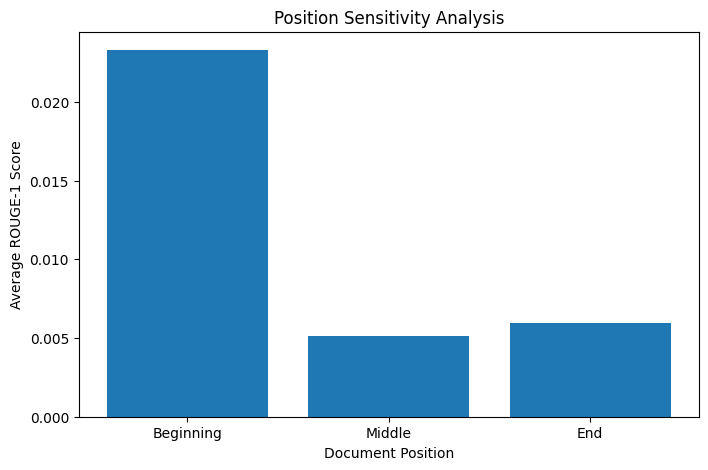

✅ Position Sensitivity Chart Saved


In [80]:
import matplotlib.pyplot as plt

positions = [
    "Beginning",
    "Middle",
    "End"
]

scores = [
    beginning_avg,
    middle_avg,
    end_avg
]

plt.figure(figsize=(8, 5))

plt.bar(
    positions,
    scores
)

plt.xlabel("Document Position")
plt.ylabel("Average ROUGE-1 Score")
plt.title("Position Sensitivity Analysis")

plt.savefig(
    "results/position_sensitivity_chart.png"
)

plt.show()

print("✅ Position Sensitivity Chart Saved")

In [81]:
import os

print(
    os.listdir("results")
)

['rag_answers.json', 'evaluation_scores.json', 'long_context_answers.json', 'position_sensitivity_analysis.json', 'position_sensitivity_chart.png']


In [1]:
import time
import torch
import psutil

In [3]:
from datasets import load_dataset

dataset = load_dataset("deepmind/narrativeqa")

test_dataset = dataset["test"]

subset_dataset = test_dataset.select(range(200))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/24 [00:00<?, ?it/s]

data/train-00005-of-00024.parquet:   0%|          | 0.00/206M [00:00<?, ?B/s]

...

data/validation-00002-of-00003.parquet:   0%|          | 0.00/68.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/32747 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10557 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3461 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

In [4]:
processed_data = []

for item in subset_dataset:

    processed_item = {
        "document": item["document"]["text"],
        "question": item["question"]["text"],
        "reference_answer": item["answers"][0]["text"]
    }

    processed_data.append(processed_item)

print(
    "✅ Processed Samples:",
    len(processed_data)
)

✅ Processed Samples: 200


In [5]:
benchmark_sample = processed_data[0]

print(
    benchmark_sample["question"]
)

Who is Mark Hunter?


In [12]:
!pip install -q langchain-text-splitters

In [10]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=512,
    chunk_overlap=50
)

print("✅ text_splitter Restored")

✅ text_splitter Restored


In [14]:
!pip install -q sentence-transformers

In [15]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("✅ Embedding Model Restored")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Embedding Model Restored


In [17]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "mistralai/Mistral-7B-Instruct-v0.2"

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("✅ tokenizer and model Restored")

config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

✅ tokenizer and model Restored


In [18]:
import time
import torch
import psutil

sample_prompt = """
You are an intelligent AI assistant.

Answer the following question.

Question:
Who is Mark Hunter?

Answer:
"""

start_time = time.time()

inputs = tokenizer(
    sample_prompt,
    return_tensors="pt"
).to("cuda")

outputs = model.generate(
    **inputs,
    max_new_tokens=60,
    do_sample=False
)

end_time = time.time()

latency = end_time - start_time

generated_tokens = outputs[0].shape[0]

throughput = generated_tokens / latency

gpu_memory = torch.cuda.memory_allocated()

gpu_memory_gb = gpu_memory / (1024 ** 3)

cpu_memory = psutil.virtual_memory().used

cpu_memory_gb = cpu_memory / (1024 ** 3)

performance_metrics = {
    "latency_seconds": float(latency),
    "throughput_tokens_per_second": float(throughput),
    "gpu_memory_gb": float(gpu_memory_gb),
    "cpu_memory_gb": float(cpu_memory_gb)
}

print(performance_metrics)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


{'latency_seconds': 21.843987464904785, 'throughput_tokens_per_second': 4.303243634021639, 'gpu_memory_gb': 12.524656772613525, 'cpu_memory_gb': 6.787273406982422}


In [20]:
import os

os.makedirs(
    "results",
    exist_ok=True
)

print("✅ results folder recreated")

✅ results folder recreated


In [22]:
import json
with open(
    "results/performance_metrics.json",
    "w"
) as f:

    json.dump(
        performance_metrics,
        f,
        indent=4
    )

print(
    "✅ performance_metrics.json Saved"
)

✅ performance_metrics.json Saved


In [23]:
import os

print(
    os.listdir("results")
)

['performance_metrics.json']


In [24]:
from google.colab import files

files.download("results/performance_metrics.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>